# Clasificación CIFAR-10: Regresión Logística Multinomial (One-vs-All)

Este cuaderno tiene como objetivo clasificar imágenes del dataset CIFAR-10 utilizando el algoritmo One-vs-All implementado desde cero. CIFAR-10 consta de 60,000 imágenes a color de 32x32 píxeles divididas en 10 clases.


## Fase 1: Carga y Preprocesamiento de CIFAR-10

Cargamos los lotes de datos, extraemos las etiquetas y normalizamos las intensidades de los píxeles (0-255) al rango [0, 1].

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from scipy import optimize

%matplotlib inline

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

ruta_cifar = '../Datasets/3_cifar-10-batches-py/'

# Cargamos metadatos para los nombres de las clases
meta = unpickle(os.path.join(ruta_cifar, 'batches.meta'))
nombres_clases = [n.decode('utf-8') for n in meta[b'label_names']]

# Cargamos todos los lotes de entrenamiento (data_batch_1 a 5)
X_train_list = []
y_train_list = []

for i in range(1, 6):
    batch = unpickle(os.path.join(ruta_cifar, f'data_batch_{i}'))
    X_train_list.append(batch[b'data'])
    y_train_list.extend(batch[b'labels'])

X_train = np.vstack(X_train_list)
y_train = np.array(y_train_list)

# Cargamos el lote de prueba
test_batch = unpickle(os.path.join(ruta_cifar, 'test_batch'))
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

print(f"Dataset cargado exitosamente.")
print(f"Entrenamiento: {X_train.shape} imágenes")
print(f"Prueba: {X_test.shape} imágenes")
print(f"Clases: {nombres_clases}")
print(f"Numero de clases: {len(nombres_clases)}")

ModuleNotFoundError: No module named 'numpy'

### Muestra 30 imagenes aletaorias del conjunto de entrenamiento

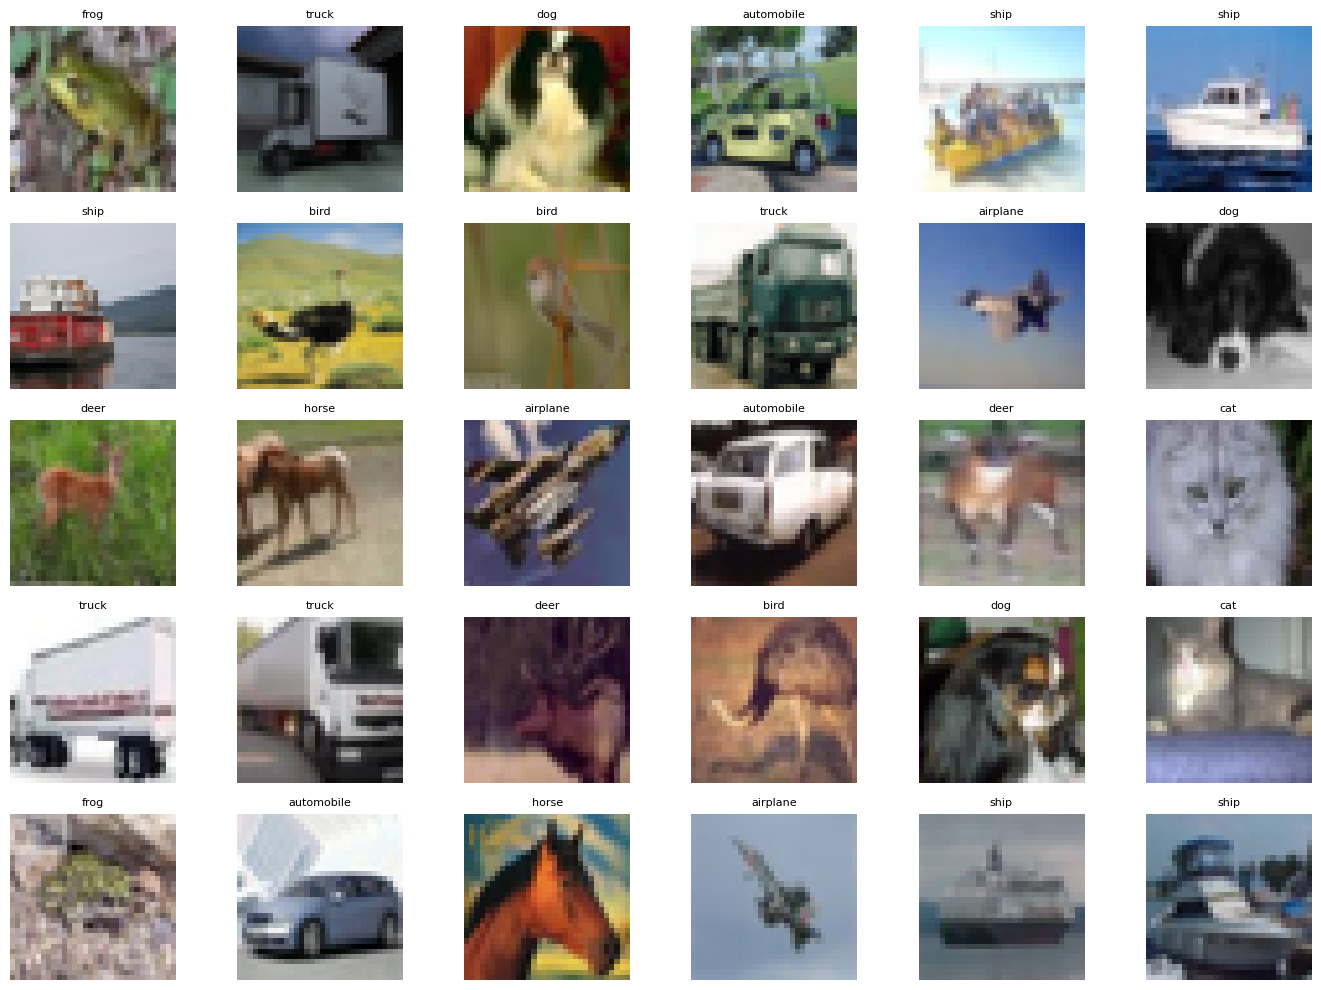

In [ ]:
num_imgs = 30
indices = np.random.choice(X_train.shape[0], num_imgs, replace=False)

fig, axes = plt.subplots(5, 6, figsize=(14, 10))

for ax, idx in zip(axes.ravel(), indices):
    # CIFAR-10 está aplanado como (3072,) = (3, 32, 32)
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)
    ax.imshow(img.astype(np.uint8))
    ax.set_title(nombres_clases[y_train[idx]], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Normalización y Preparación
Escalamos los valores de los píxeles dividiendo por 255.

In [ ]:
# Normalización simple al rango [0, 1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("Valores mín/máx después de normalizar:", X_train_norm.min(), X_train_norm.max())

Valores mín/máx después de normalizar: 0.0 1.0


## Fase 2: Funciones del Modelo (One-vs-All)

Implementamos Sigmoide, Costo, Gradiente y Predicción.

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    if y.dtype == bool:
        y = y.astype(float)
        
    h = sigmoid(X.dot(theta.T))
    
    temp = theta.copy()
    temp[0] = 0
    
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp
    
    return J, grad

def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    return np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

def oneVsAll(X, y, num_labels, lambda_, maxiter=100):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Historial por clase para construir curvas de costo/precisión
    theta_history = []
    cost_history = []
    
    for c in range(num_labels):
        print(f"Entrenando clasificador para la clase {c} ({nombres_clases[c]})...")
        initial_theta = np.zeros(n + 1)
        y_bin = (y == c).astype(float)

        class_theta_hist = [initial_theta.copy()]
        class_cost_hist = [lrCostFunction(initial_theta, X_bias, y_bin, lambda_)[0]]

        def callback(theta_k):
            class_theta_hist.append(theta_k.copy())
            class_cost_hist.append(lrCostFunction(theta_k, X_bias, y_bin, lambda_)[0])
        
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X_bias, y_bin, lambda_),
            jac=True,
            method='CG',
            callback=callback,
            options={'maxiter': maxiter}
        )
        
        all_theta[c] = res.x
        theta_history.append(class_theta_hist)
        cost_history.append(class_cost_hist)
        
    history = {
        'theta_history': theta_history,
        'cost_history': cost_history
    }
    return all_theta, history

def build_training_curves(theta_history, cost_history, X_train, y_train, eval_every=5):
    num_labels = len(theta_history)
    max_steps = max(len(h) for h in theta_history)
    steps = list(range(0, max_steps, eval_every))
    if steps[-1] != max_steps - 1:
        steps.append(max_steps - 1)

    cost_curve = []
    precision_curve = []

    for t in steps:
        theta_snapshot = []
        costs_t = []
        
        for c in range(num_labels):
            idx_t = min(t, len(theta_history[c]) - 1)
            theta_snapshot.append(theta_history[c][idx_t])
            costs_t.append(cost_history[c][idx_t])

        theta_snapshot = np.vstack(theta_snapshot)
        pred_t = predictOneVsAll(theta_snapshot, X_train)
        acc_t = np.mean(pred_t == y_train) * 100

        cost_curve.append(float(np.mean(costs_t)))
        precision_curve.append(float(acc_t))

    return np.array(steps), np.array(cost_curve), np.array(precision_curve)

## Fase 3: Entrenamiento y Resultados

Nota: Debido al tamaño de CIFAR-10 (3072 dimensiones), el entrenamiento puede tardar unos minutos. Usaremos un subconjunto más pequeño si es necesario, o pocas iteraciones.

In [ ]:
num_labels = 10
lambda_ = 0.1
fraccion_train = 0.8

# Split estratificado por clase: 80% train y 20% validación
rng = np.random.default_rng(42)
indices_train = []
indices_val = []

for c in range(num_labels):
    idx_clase = np.where(y_train == c)[0]
    idx_clase_mezclado = rng.permutation(idx_clase)
    n_train_clase = int(len(idx_clase_mezclado) * fraccion_train)
    
    indices_train.append(idx_clase_mezclado[:n_train_clase])
    indices_val.append(idx_clase_mezclado[n_train_clase:])

indices_train = np.concatenate(indices_train)
indices_val = np.concatenate(indices_val)
rng.shuffle(indices_train)
rng.shuffle(indices_val)

X_train_bal = X_train_norm[indices_train]
y_train_bal = y_train[indices_train]
X_val_bal = X_train_norm[indices_val]
y_val_bal = y_train[indices_val]

conteos_train = np.bincount(y_train_bal, minlength=num_labels)
conteos_val = np.bincount(y_val_bal, minlength=num_labels)
print("Conteo por clase en TRAIN (80%):", conteos_train)
print("Total TRAIN:", len(y_train_bal))
print("Conteo por clase en VAL (20%):", conteos_val)
print("Total VAL:", len(y_val_bal))

all_theta, history = oneVsAll(X_train_bal, y_train_bal, num_labels, lambda_, maxiter=100)
print("Entrenamiento completado.")

Conteo por clase en TRAIN (80%): [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000]
Total TRAIN: 40000
Conteo por clase en VAL (20%): [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Total VAL: 10000
Entrenando clasificador para la clase 0 (airplane)...
Entrenando clasificador para la clase 1 (automobile)...
Entrenando clasificador para la clase 2 (bird)...
Entrenando clasificador para la clase 3 (cat)...
Entrenando clasificador para la clase 4 (deer)...
Entrenando clasificador para la clase 5 (dog)...
Entrenando clasificador para la clase 6 (frog)...
Entrenando clasificador para la clase 7 (horse)...
Entrenando clasificador para la clase 8 (ship)...
Entrenando clasificador para la clase 9 (truck)...
Entrenamiento completado.


### Evaluación de Precisión

Precisión en entrenamiento (80%): 45.30%
Precisión en validación (20%): 41.15%


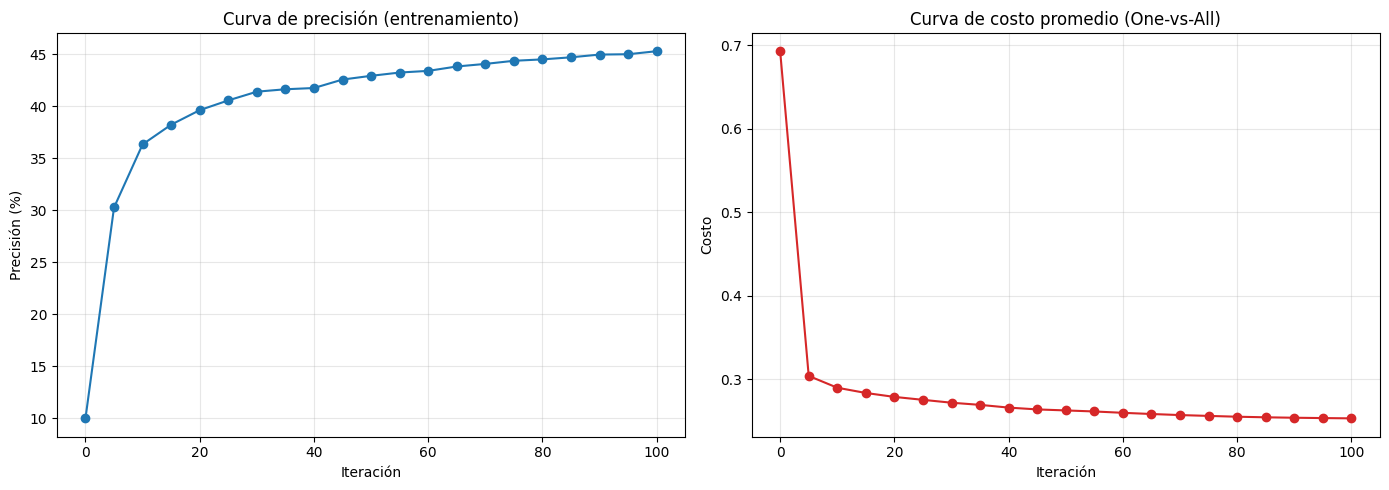

In [ ]:
# Precisión de entrenamiento
pred_train = predictOneVsAll(all_theta, X_train_bal)
acc_train = np.mean(pred_train == y_train_bal) * 100
print(f"Precisión en entrenamiento (80%): {acc_train:.2f}%")

# Precisión de validación y test
pred_val = predictOneVsAll(all_theta, X_val_bal)
acc_val = np.mean(pred_val == y_val_bal) * 100
print(f"Precisión en validación (20%): {acc_val:.2f}%")

# Curvas de entrenamiento (costo y precisión)
steps, cost_curve, precision_curve = build_training_curves(
    history['theta_history'],
    history['cost_history'],
    X_train_bal,
    y_train_bal,
    eval_every=5
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(steps, precision_curve, marker='o')
axes[0].set_title('Curva de precisión (entrenamiento)')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Precisión (%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, cost_curve, marker='o', color='tab:red')
axes[1].set_title('Curva de costo promedio (One-vs-All)')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Costo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualización de Predicciones Reales

Mostramos imágenes aleatorias del conjunto de prueba (20%) comparando la etiqueta real con la predicción.

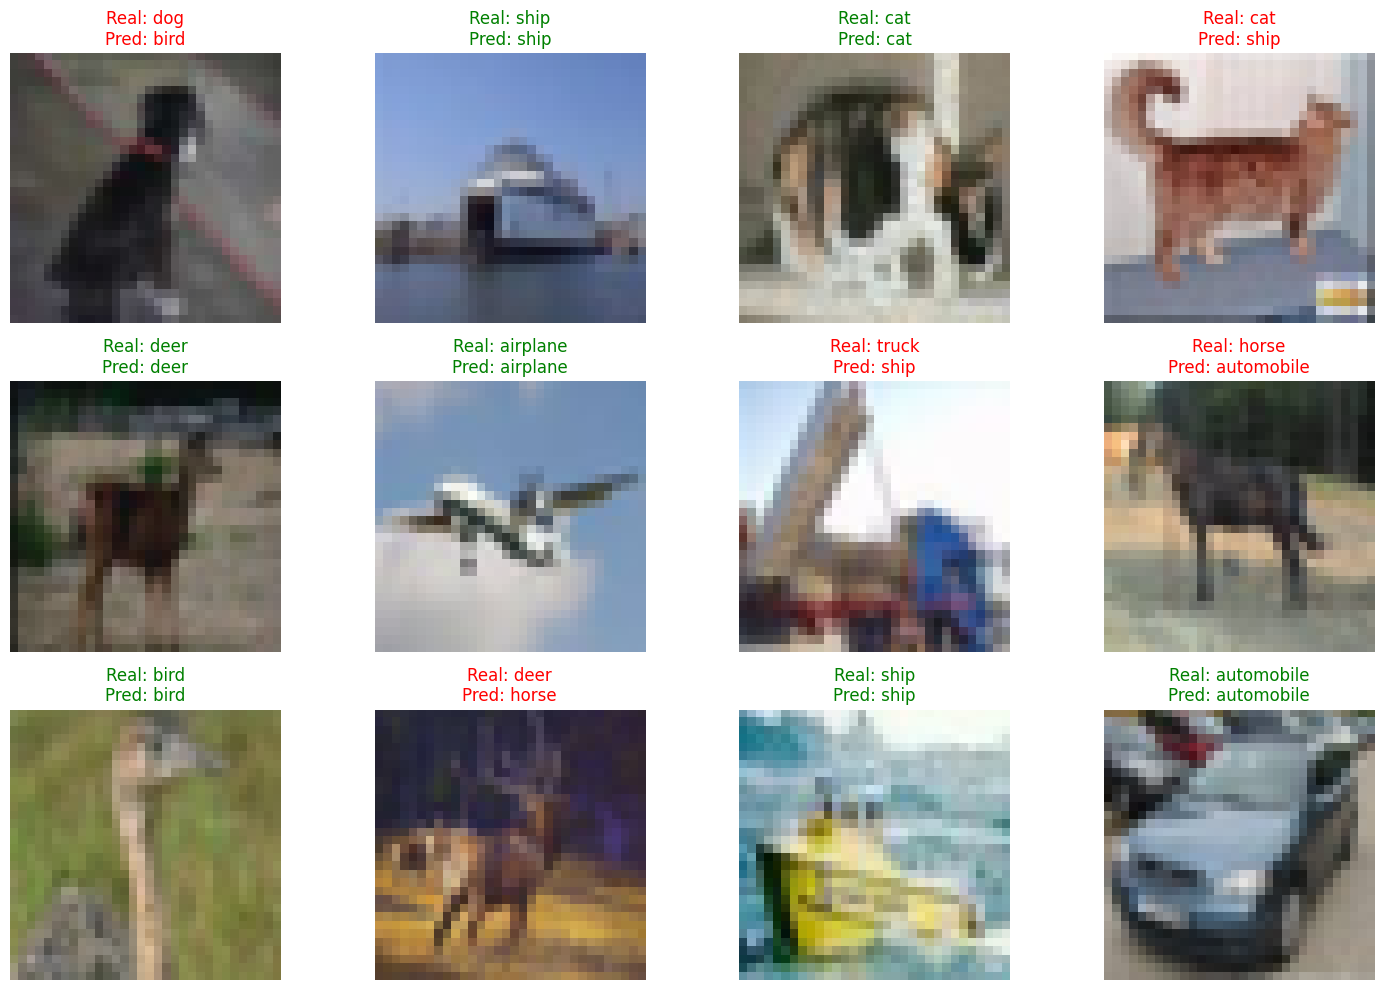

In [ ]:
# Predicciones sobre test (usar datos normalizados para el modelo)
pred_test = predictOneVsAll(all_theta, X_test_norm)

def visualizar_cifar(X_raw, y_real, y_pred, nombres_clases, num_muestras=12):
    plt.figure(figsize=(15, 10))
    num_muestras = min(num_muestras, len(X_raw))
    indices = np.random.choice(len(X_raw), num_muestras, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(3, 4, i + 1)
        
        # Reshape de (3072,) -> (3, 32, 32) -> (32, 32, 3)
        img = X_raw[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        plt.imshow(img)
        
        real_name = nombres_clases[y_real[idx]]
        pred_name = nombres_clases[y_pred[idx]]
        
        color = 'green' if y_real[idx] == y_pred[idx] else 'red'
        plt.title(f"Real: {real_name}\nPred: {pred_name}", color=color)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

# Visualización usando X_test original (sin normalizar) para ver mejor la imagen
visualizar_cifar(X_test, y_test, pred_test, nombres_clases)

## Predicción de imagen externa (truck.jpg)

Cargamos la imagen, la convertimos a **28x28**, luego la centramos sobre un lienzo **32x32** para que coincida con el tamaño de entrada del modelo entrenado.

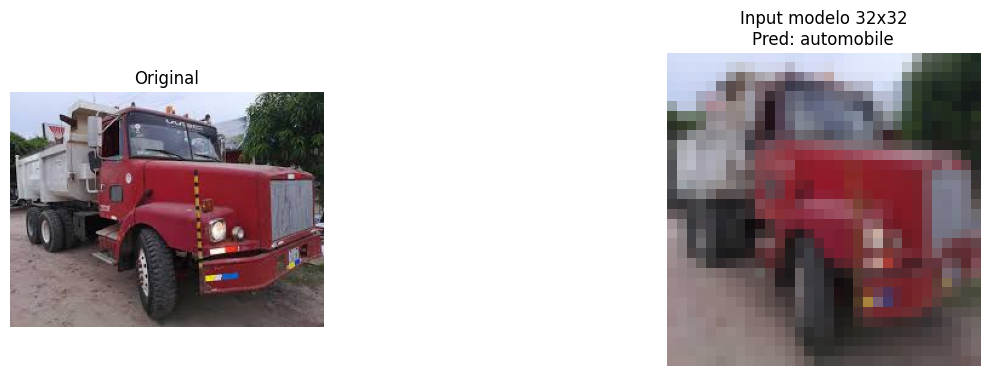

Imagen usada: ../Datasets/3_cifar-10-batches-py/truck.jpg
Clase predicha: automobile (label 1)


In [ ]:
from PIL import Image

# Probamos ambas rutas para que funcione desde distintas ubicaciones de ejecución
candidatas = [
    'Datasets/3_cifar-10-batches-py/truck.jpg',
    '../Datasets/3_cifar-10-batches-py/truck.jpg'
 ]
imagen_path = next((p for p in candidatas if os.path.exists(p)), None)

if imagen_path is None:
    raise FileNotFoundError('No se encontró truck.jpg en las rutas esperadas.')

# 1) Carga en RGB
img = Image.open(imagen_path).convert('RGB')

# 2) Conversión solicitada a 28x28
img_28 = img.resize((32, 32), Image.Resampling.BILINEAR)
arr_28 = np.array(img_28, dtype=np.float32)

# 4) Normalización y vectorización
x_input = (arr_28 / 255.0).reshape(1, -1)

# 5) Predicción
pred_img = predictOneVsAll(all_theta, x_input)[0]
clase_predicha = nombres_clases[pred_img]

# 6) Visualización
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.array(img))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(arr_28.astype(np.uint8))
plt.title(f'Input modelo 32x32\nPred: {clase_predicha}')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Imagen usada: {imagen_path}')
print(f'Clase predicha: {clase_predicha} (label {pred_img})')